# 第2回講義 演習

今回は，深層モデルやそのライブラリは用いず，機械学習の基礎を理解するために，まず回帰問題を扱い，その後ロジスティック回帰およびソフトマックス回帰を実装します．

なお，ロジスティック回帰やソフトマックス回帰は名前に「回帰」とありますが，分類問題であることに注意してください.  
シグモイド関数を用いることで，データのラベルが 1 または 0 である確率を出力します．

## 目次

1. [【課題 1】回帰問題と平均二乗誤差 (MSE)](#scrollTo=t4lVHe-VtcDY&line=5&uniqifier=1)

    1.1. [データセットの作成]()

    1.2. [モデル・損失関数・学習方法]()

    1.3. [学習前の予測]()

    1.4. [学習]()

    1.5. [学習結果の確認]()

1. [【課題 2】ロジスティック回帰の実装と学習 (OR)](#scrollTo=quBPRwBf4Kq7&line=1&uniqifier=1)
    
    2.1. [シグモイド関数](#scrollTo=awSlFgRA4Kq9)

    2.2. [データセットの設定と重みの定義](#scrollTo=HAA-lvhz4KrF)
    
    2.3. [train関数とvalid関数](#scrollTo=7raMb3ts4KrL)
    
    2.4. [学習](#scrollTo=LiuO_6B-4Krb)

1. [【課題 3】ソフトマックス回帰の実装と学習 (MNIST)](#scrollTo=44tdPsW34Krq&line=1&uniqifier=1)
    
    3.1. [ソフトマックス関数](#scrollTo=YEprLDMd4Krr)
    
    3.2. [データセットの設定と重みの定義](#scrollTo=52fR-55x4Krx)
    
    3.3. [train関数とvalid関数](#scrollTo=80EOFI-n4Kr6)

    3.4. [学習](#scrollTo=JBGInXhG4KsJ)

In [5]:
import os
os.environ["KERAS_BACKEND"] = "torch"

In [6]:
# Library Import
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from keras.datasets import mnist
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

np.random.seed(34)

## 1.【課題 1】回帰問題と平均二乗誤差 (MSE)

まず最も基本的な例として，連続値を予測する回帰問題を考える．  
ここでは，ニューラルネットワークの学習の基本構造を，  
平均二乗誤差 (Mean Squared Error; MSE)を用いて確認する．

### 1.1. データセットの作成

1次元入力 $x$ に対して，連続値 $y$ を出力する回帰データを作成する．  
ここでは，ノイズを含む線形関数を用いる．

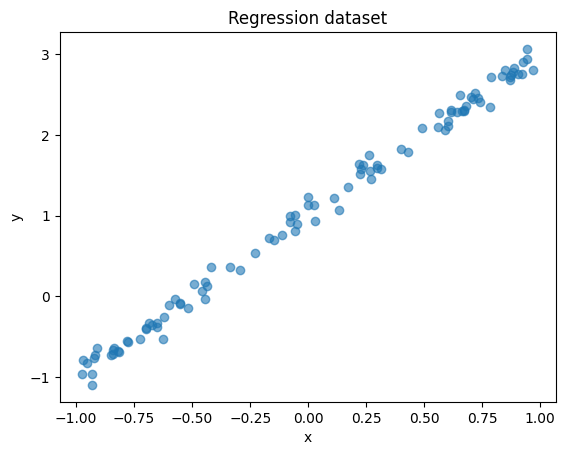

In [7]:
# データ数
N = 100

# input 
x = np.random.uniform(-1, 1, (N, 1))

# Ground truth value
y = 2*x + 1 + 0.1 * np.random.randn(N, 1)

# 可視化
plt.scatter(x, y, alpha=0.6)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Regression dataset')
plt.show()

### 1.2. モデル・損失関数・学習方法

回帰問題では，入力 $x$ から出力 $\hat{y}$ を予測するモデルを学習する．  
ここでは最も単純なニューラルネットワークとして，線形変換を用いる．

$\hat{y} = Wx + b$

モデルの学習には，予測値と正解値の差を測る  
平均二乗誤差 (Mean Squared Error; MSE)を用いる．

$\mathrm{MSE} = \frac{1}{N}\sum_{i=1}^N (y_i - \hat{y}_i)^2$

勾配降下法により，MSE を最小化するように  
パラメータ $W, b$ を更新する．

In [ ]:
# パラメータの初期化
W = np.random.randn(1,1)
b = np.zeros((1,))

# 平均二乗誤差（MSE）の定義
def mse(y, y_hat):
    return np.mean((y-y_hat) ** 2)

# Learning Function
def train(x, y, W, b, lr=0,1):
    # prediction
    y_hat = x @ W + b

    # loss
    loss = mse(y, y_hat)

    